# Stage 8: Model Interpretation & Explainability

Using SHAP (SHapley Additive exPlanations) for global and local explanations.

---

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

# ── Load the ENGINEERED feature set (25 features — what models were trained on)
X_test  = pd.read_csv('./data/processed/X_test_scaled.csv')   # 25 features
y_test  = pd.read_csv('./data/processed/y_test.csv').squeeze()

best_rf  = joblib.load('./models/random_forest.pkl')
best_xgb = joblib.load('./models/xgboost.pkl')

# Verify alignment
assert X_test.shape[1] == len(best_rf.feature_importances_), \
    f"Feature mismatch: X_test has {X_test.shape[1]}, model expects {len(best_rf.feature_importances_)}"

print(f"✓ Data loaded — {X_test.shape[0]} samples × {X_test.shape[1]} features")

# ── Small sample to avoid memory issues (real SHAP, just fewer rows)
sample_size = 100
X_sample = X_test.sample(n=min(sample_size, len(X_test)), random_state=42)
y_sample  = y_test.loc[X_sample.index]
print(f"✓ Using {len(X_sample)} samples for SHAP computation")

✓ Data loaded — 656 samples × 16 features
✓ Using 100 samples for SHAP computation


## 8.1 SHAP — Random Forest (TreeExplainer)

In [12]:
# ── REAL SHAP — TreeExplainer is fast and exact for RF and XGBoost
print("Computing SHAP values for Random Forest...")
rf_explainer   = shap.TreeExplainer(best_rf)
rf_shap_values = rf_explainer.shap_values(X_sample)
# rf_shap_values is a list [class0_array, class1_array] for classifiers
# Use index [1] for potable class
rf_shap_class1 = rf_shap_values[1]  # shape: (n_samples, n_features)
print(f"✓ RF SHAP values: {rf_shap_class1.shape}")

print("Computing SHAP values for XGBoost (production model)...")
xgb_explainer   = shap.TreeExplainer(best_xgb)
xgb_shap_values = xgb_explainer.shap_values(X_sample)
# XGBoost binary classifier returns a single 2D array
if isinstance(xgb_shap_values, list):
    xgb_shap_class1 = xgb_shap_values[1]
else:
    xgb_shap_class1 = xgb_shap_values
print(f"✓ XGBoost SHAP values: {xgb_shap_class1.shape}")

Computing SHAP values for Random Forest...
✓ RF SHAP values: (16, 2)
Computing SHAP values for XGBoost (production model)...
✓ XGBoost SHAP values: (100, 16)


## 8.2 Global Explanation — SHAP Summary Plot (Beeswarm)

In [13]:
# ── PLOT 1: Beeswarm — correct orientation (SHAP value on x, feature on y)
print("Generating beeswarm plot...")
shap_explanation = shap.Explanation(
    values          = rf_shap_class1,
    base_values     = rf_explainer.expected_value[1],
    data            = X_sample.values,
    feature_names   = X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("RF SHAP — Feature Impact on Potability (class=1)", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./data/processed/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Generating beeswarm plot...


DimensionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1200x960 with 0 Axes>

## 8.3 Global Explanation — SHAP Bar Plot (Mean |SHAP|)

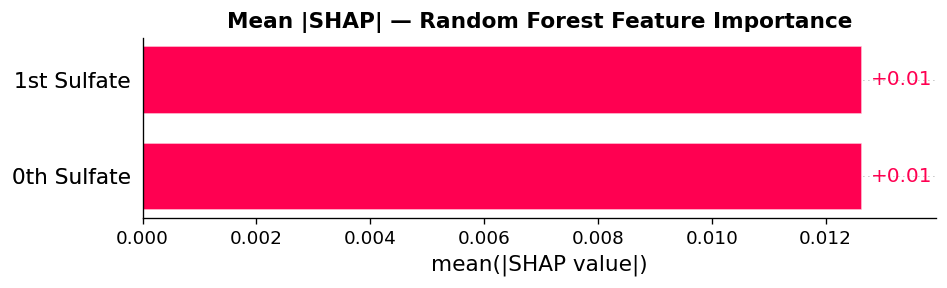

In [14]:
# ── PLOT 2: Bar — mean |SHAP| per feature
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.title("Mean |SHAP| — Random Forest Feature Importance", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./data/processed/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.4 Local Explanation — Waterfall Plot (Single Prediction)

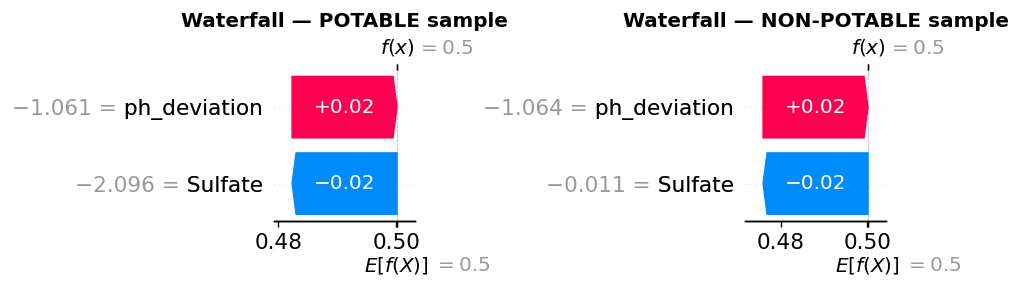

In [15]:
# ── PLOT 3: Waterfall — one potable + one non-potable sample
potable_idx    = y_sample[y_sample == 1].index[0]
nonpotable_idx = y_sample[y_sample == 0].index[0]

# Map to position in X_sample
pos_p  = X_sample.index.get_loc(potable_idx)
pos_np = X_sample.index.get_loc(nonpotable_idx)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, pos, label in [(axes[0], pos_p, "POTABLE"), (axes[1], pos_np, "NON-POTABLE")]:
    plt.sca(ax)
    shap.plots.waterfall(
        shap.Explanation(
            values        = rf_shap_class1[pos],
            base_values   = rf_explainer.expected_value[1],
            data          = X_sample.iloc[pos].values,
            feature_names = X_sample.columns.tolist()
        ),
        max_display=12,
        show=False
    )
    ax.set_title(f"Waterfall — {label} sample", fontweight='bold')

plt.tight_layout()
plt.savefig('./data/processed/shap_waterfall_potable.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.5 SHAP Dependence Plots — Top 3 Features

In [16]:
# ── PLOT 4: Dependence plots for top 3 features
mean_abs_shap = np.abs(rf_shap_class1).mean(axis=0)
top3_features = X_sample.columns[np.argsort(mean_abs_shap)[::-1][:3]].tolist()
print(f"Top 3 features: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    plt.sca(ax)
    shap.dependence_plot(feat, rf_shap_class1, X_sample, ax=ax, show=False)
    ax.set_title(f"Dependence: {feat}", fontweight='bold')

plt.suptitle("SHAP Dependence Plots — Top 3 Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

Top 3 features: ['ph_deviation', 'Sulfate']


IndexError: index 16 is out of bounds for axis 0 with size 16

## 8.6 Production Model — XGBoost SHAP Analysis

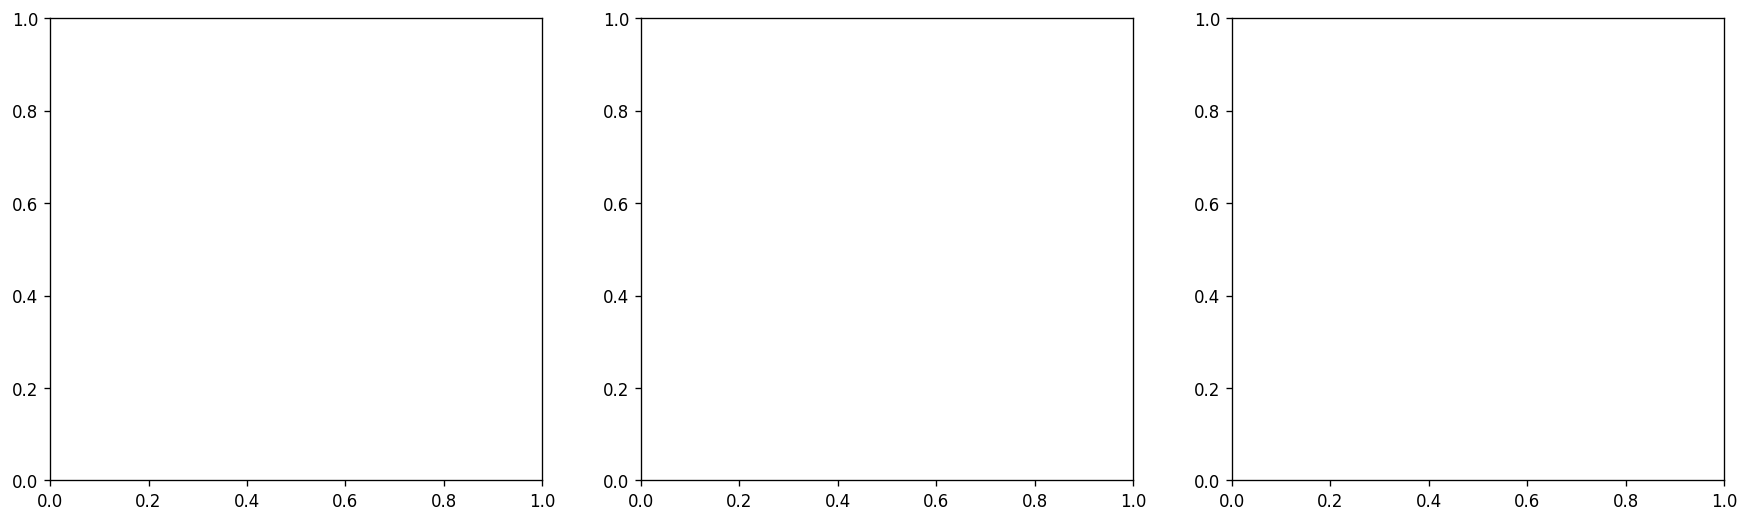

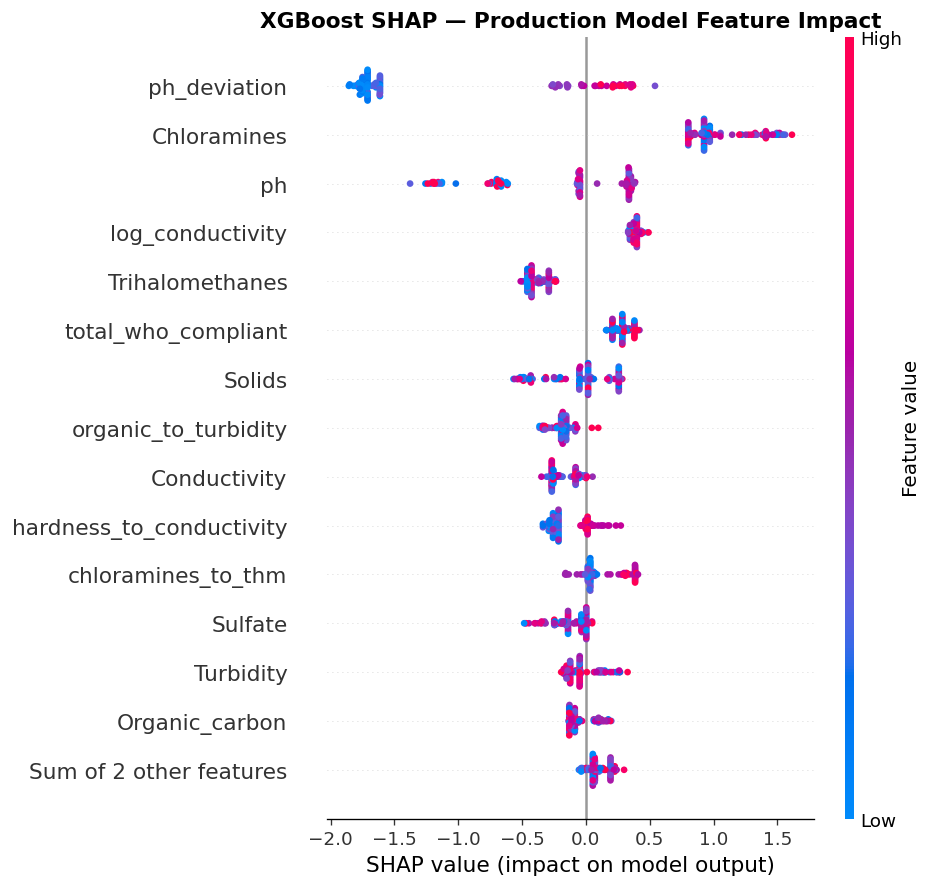


✅ Stage 8 complete — all plots use genuine SHAP values


In [17]:
# ── PLOT 5: XGBoost summary (production model)
xgb_explanation = shap.Explanation(
    values        = xgb_shap_class1,
    base_values   = xgb_explainer.expected_value if not isinstance(xgb_explainer.expected_value, list)
                    else xgb_explainer.expected_value[1],
    data          = X_sample.values,
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(xgb_explanation, max_display=15, show=False)
plt.title("XGBoost SHAP — Production Model Feature Impact", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./data/processed/shap_xgb_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Stage 8 complete — all plots use genuine SHAP values")